In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [72]:
matches=pd.read_csv('../../../data/processed/Matches/Matches_cleaned_2526.csv')
teams=pd.read_csv('../../../data/processed/Teams/2526_Major_Leagues.csv')

In [73]:
matches.head()

,competition_code,home_team,away_team,goal_difference,home_id,away_id
0,PL,AFC Bournemouth,Liverpool FC,-2,60,44
1,PL,Aston Villa FC,Newcastle United FC,0,40,39
2,PL,Fulham FC,Brighton & Hove Albion FC,0,43,30
3,PL,Sunderland AFC,West Ham United FC,3,41,37
4,PL,Burnley FC,Tottenham Hotspur FC,-3,6,33


In [74]:
teams.head()

,f_assists_per90_zscore,f_expectedassists_per90_zscore,f_keypasses_per90_zscore,f_bigchancescreated_per90_zscore,f_goalconversionpercentage_zscore,f_defensive_actions_zscore,f_aerialduelswonpercentage_zscore,m_goals_per90_zscore,m_expectedgoals_per90_zscore,m_shotsontarget_per90_zscore,...,eng_defense,eng_pressing,eng_buildup,eng_aerial,eng_dribbling,eng_goalkeeper,eng_finishing,eng_transition,team,team id
0,0.696938,0.621037,0.282423,0.973585,0.249211,0.184185,-0.708001,1.180696,0.926073,0.900484,...,-0.003496,0.403786,0.702275,-0.178347,0.435135,-0.474601,0.739268,0.329255,PSV Eindhoven,2952
1,0.080423,-0.722795,0.164683,-0.145624,-0.136116,0.038764,1.451523,0.424821,0.622570,0.410066,...,0.002315,0.001475,-0.487137,0.447017,-0.268378,0.334085,0.148024,-0.077243,VfL Bochum 1848,2542
2,1.035626,-0.856866,-0.272360,-0.102304,0.779150,-0.610290,0.199111,-0.420412,-0.550005,-0.287023,...,-0.420977,-0.097103,0.439420,0.898226,-0.530032,0.961472,-0.608325,-0.065842,Sarmiento,42338
3,-0.188255,0.020997,-0.242955,0.056077,0.002151,-0.112253,-0.415128,-0.033442,-0.208656,-0.400220,...,0.063662,0.062705,-0.211847,-0.248290,-0.038090,-0.060312,-0.256993,0.022701,Valencia,2828
4,-0.561657,-0.687889,-0.921890,-0.752075,-0.633013,0.079532,0.890600,0.166783,0.086528,0.067863,...,0.118625,0.206306,-0.423434,0.344312,-0.529067,0.114295,-1.031718,-0.215299,Portsmouth,2


In [75]:
df=pd.merge(matches, teams, left_on='home_id', right_on='team id', how='left')

In [76]:
dna_cols = [col for col in teams.columns if col not in ['team', 'team_id']]
rename_home = {col: f"home_{col}" for col in dna_cols}
df = df.rename(columns=rename_home).drop(columns=['team', 'team_id_y'], errors='ignore')
df = df.rename(columns={'team_id_x': 'home_id'})

In [77]:
df_final = pd.merge(df,teams, left_on='away_id', right_on='team id', how='left')

In [78]:
rename_away = {col: f"away_{col}" for col in dna_cols}
df_final = df_final.rename(columns=rename_away).drop(columns=['team', 'team id'], errors='ignore')

In [79]:
display(df_final[['home_team', 'away_team', 'home_eng_attack', 'away_eng_attack']].head())

,home_team,away_team,home_eng_attack,away_eng_attack
0,AFC Bournemouth,Liverpool FC,0.278645,1.050217
1,Aston Villa FC,Newcastle United FC,0.708905,-0.337923
2,Fulham FC,Brighton & Hove Albion FC,0.094821,0.447138
3,Sunderland AFC,West Ham United FC,0.334563,0.959336
4,Burnley FC,Tottenham Hotspur FC,-0.496662,-0.153922


In [80]:
base_features = [
    col.replace('home_', '') for col in df_final.columns 
    if col.startswith('home_') and not col.startswith('home_id') and not col.startswith('home_team')
]

for feat in base_features:
    df_final[f"diff_{feat}"] = df_final[f"home_{feat}"] - df_final[f"away_{feat}"]

C:\Users\vibha\AppData\Local\Temp\ipykernel_19832\2044608473.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"diff_{feat}"] = df_final[f"home_{feat}"] - df_final[f"away_{feat}"]
C:\Users\vibha\AppData\Local\Temp\ipykernel_19832\2044608473.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"diff_{feat}"] = df_final[f"home_{feat}"] - df_final[f"away_{feat}"]
C:\Users\vibha\AppData\Local\Temp\ipykernel_19832\2044608473.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [81]:
df_final.columns.to_list()

['competition_code',
 'home_team',
 'away_team',
 'goal_difference',
 'home_id',
 'away_id',
 'home_f_assists_per90_zscore',
 'home_f_expectedassists_per90_zscore',
 'home_f_keypasses_per90_zscore',
 'home_f_bigchancescreated_per90_zscore',
 'home_f_goalconversionpercentage_zscore',
 'home_f_defensive_actions_zscore',
 'home_f_aerialduelswonpercentage_zscore',
 'home_m_goals_per90_zscore',
 'home_m_expectedgoals_per90_zscore',
 'home_m_shotsontarget_per90_zscore',
 'home_m_possessionwonattthird_per90_zscore',
 'home_m_interceptions_per90_zscore',
 'home_m_ballrecovery_per90_zscore',
 'home_m_defensive_actions_zscore',
 'home_m_successfuldribbles_per90_zscore',
 'home_d_defensive_actions_zscore',
 'home_d_interceptions_per90_zscore',
 'home_d_clearances_per90_zscore',
 'home_d_tackleswon_per90_zscore',
 'home_d_aerialduelswonpercentage_zscore',
 'home_d_accuratelongballs_per90_zscore',
 'home_d_possessionwonattthird_per90_zscore',
 'home_d_groundduelswonpercentage_zscore',
 'home_g_aeri

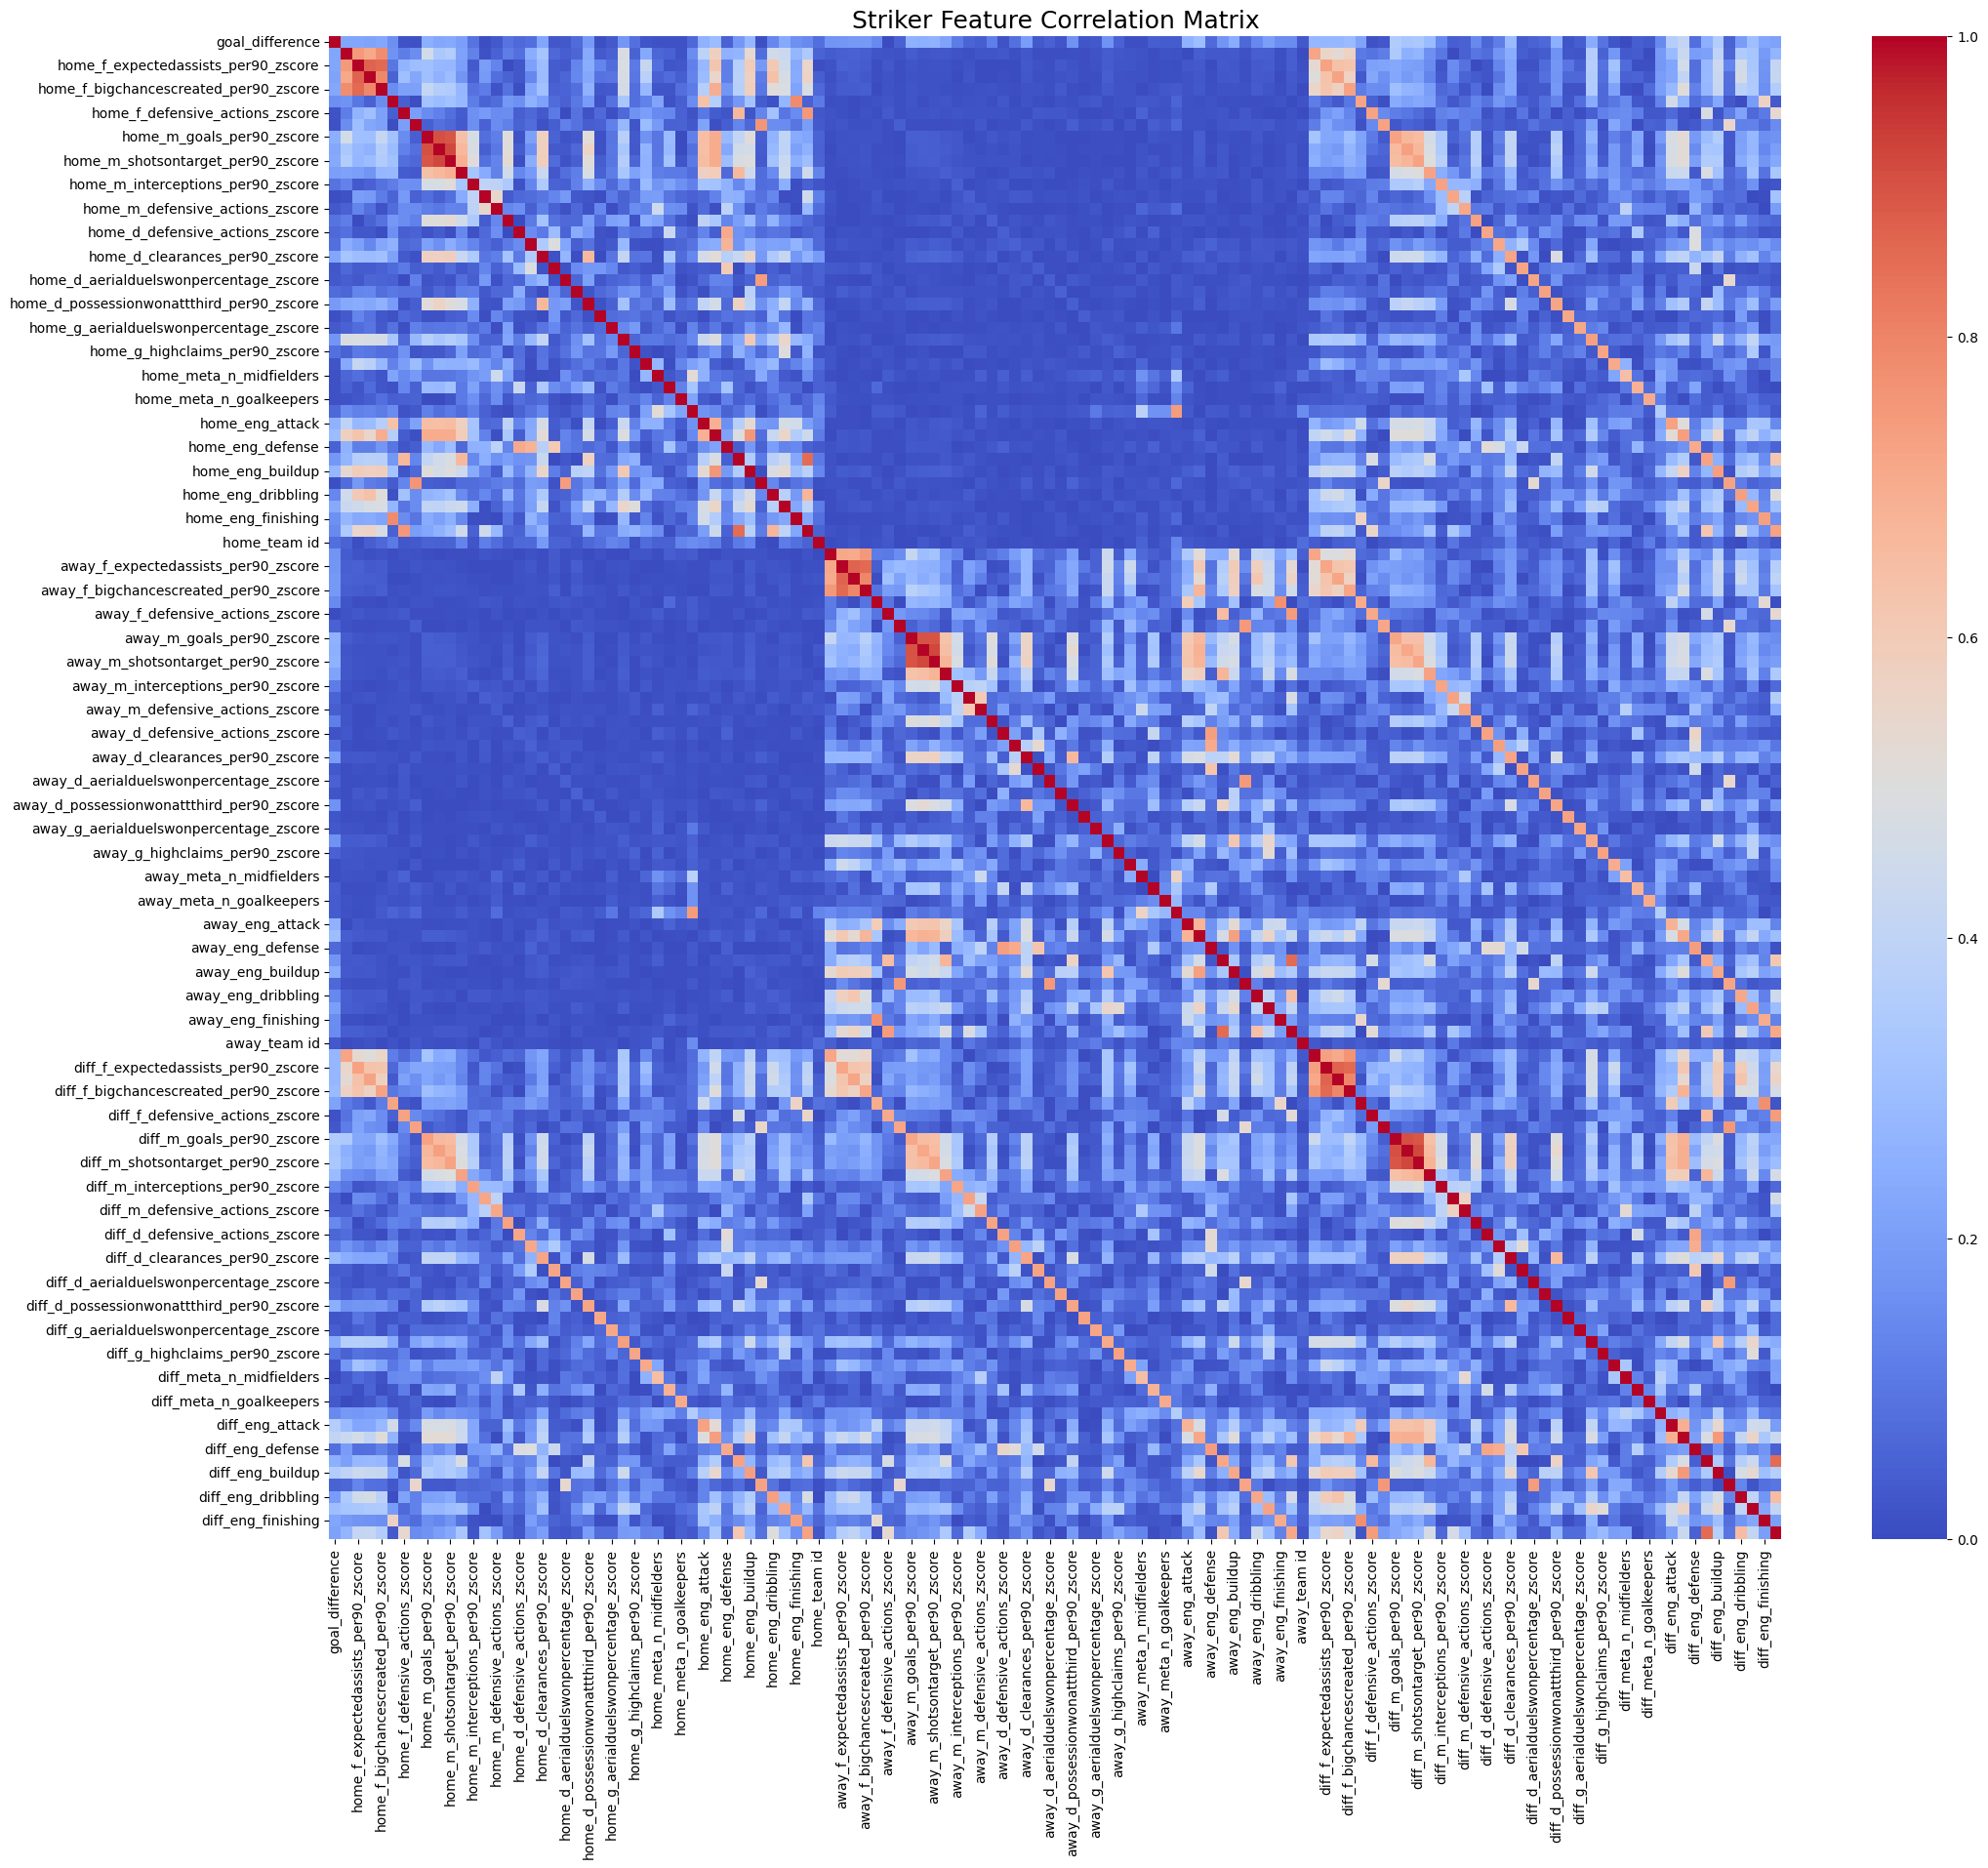

In [82]:
corr_matrix = df_final.drop(columns=['competition_code','home_team','away_team','home_id','away_id',]).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [83]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,diff_m_expectedgoals_per90_zscore,diff_m_shotsontarget_per90_zscore,0.919977
1,home_m_expectedgoals_per90_zscore,home_m_shotsontarget_per90_zscore,0.919567
2,away_m_expectedgoals_per90_zscore,away_m_shotsontarget_per90_zscore,0.919381
3,home_m_goals_per90_zscore,home_m_expectedgoals_per90_zscore,0.906233
4,diff_m_goals_per90_zscore,diff_m_expectedgoals_per90_zscore,0.904764
5,away_m_goals_per90_zscore,away_m_expectedgoals_per90_zscore,0.900817
6,away_m_goals_per90_zscore,away_m_shotsontarget_per90_zscore,0.895307
7,home_m_goals_per90_zscore,home_m_shotsontarget_per90_zscore,0.894519
8,diff_m_goals_per90_zscore,diff_m_shotsontarget_per90_zscore,0.894337
9,diff_f_expectedassists_per90_zscore,diff_f_keypasses_per90_zscore,0.870007


In [84]:
drops = [
    'm_expectedgoals_per90_zscore',
    'm_goals_per90_zscore',
    'f_expectedassists_per90_zscore'
]

dropping = []
for base in drops:
    dropping.append(f"home_{base}")
    dropping.append(f"away_{base}")
    dropping.append(f"diff_{base}")
    
df_final=df_final.drop(columns=dropping)

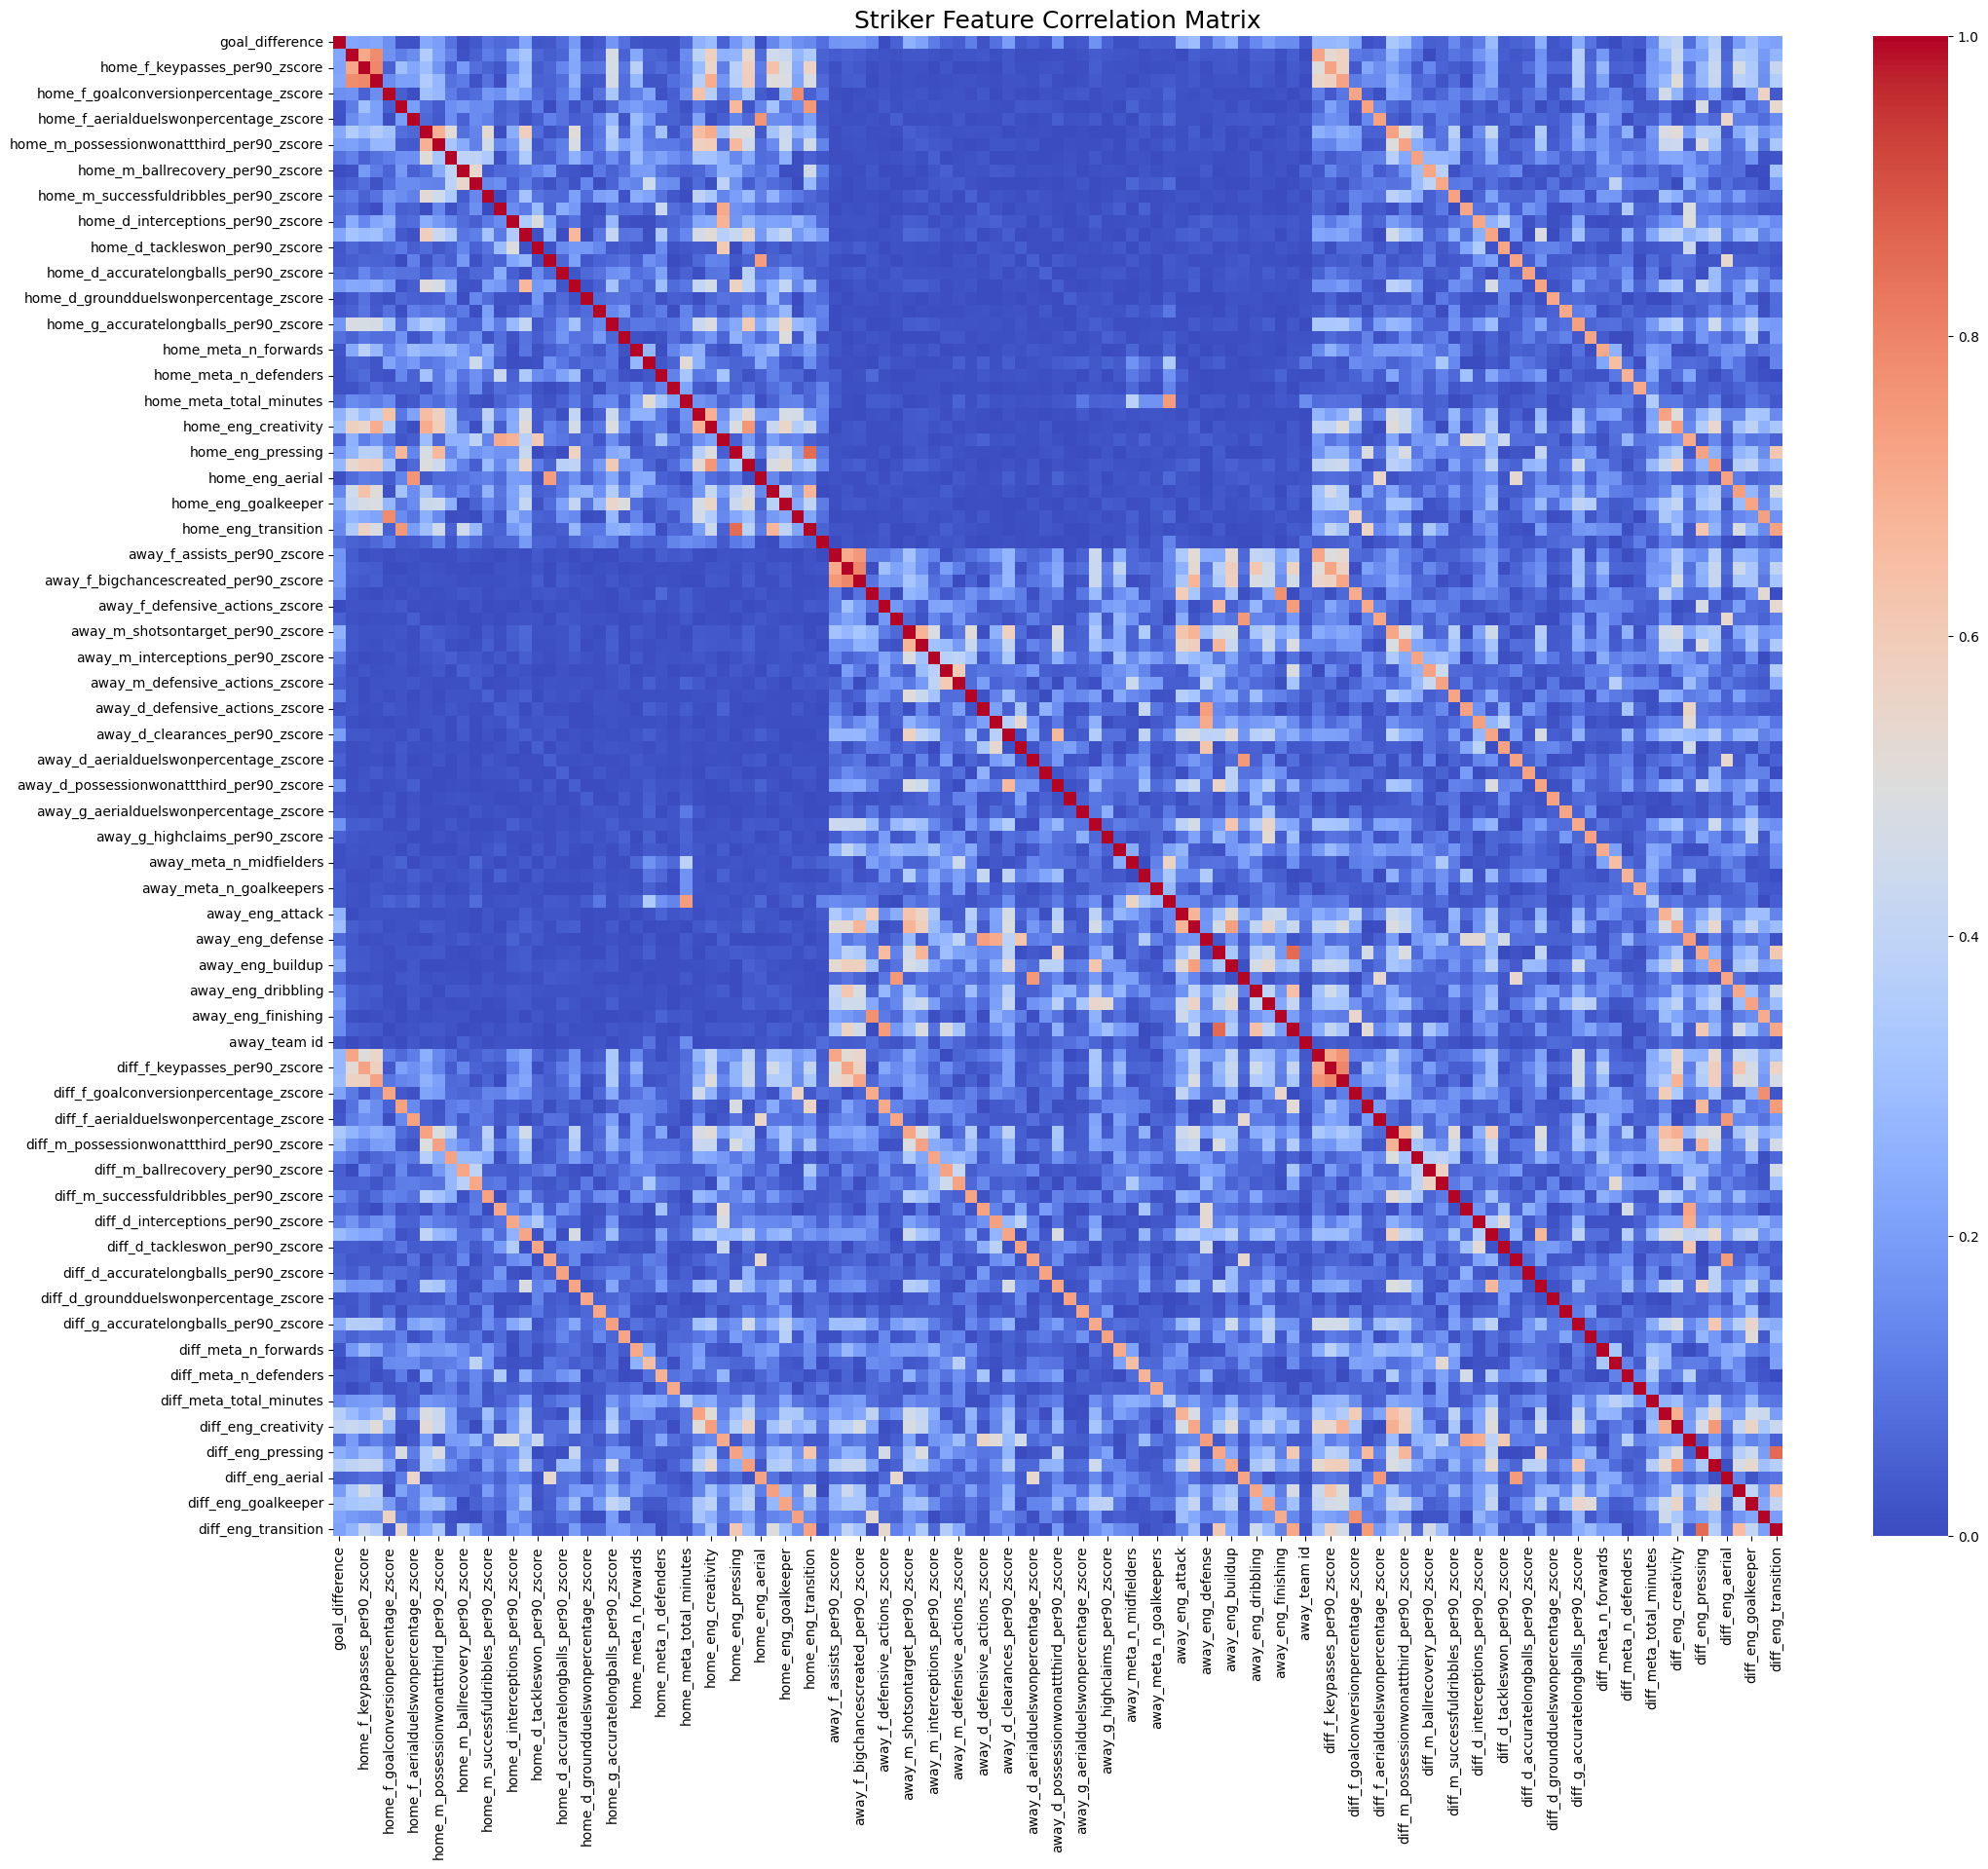

In [85]:
corr_matrix = df_final.drop(columns=['competition_code','home_team','away_team','home_id','away_id',]).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [86]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,away_eng_pressing,away_eng_transition,0.855401
1,diff_eng_pressing,diff_eng_transition,0.852409
2,home_eng_pressing,home_eng_transition,0.850236


In [87]:
df_final.to_csv('2526_Major_Leagues_cleaned.csv',index=False)